In [6]:
import sys

import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import yaml

sys.path.append("..")
from src import models, datasets, trainer, analysis

In [41]:
dir = glob.glob('../rnn_results/*')[169]
print(dir)
dir = '../rnn_results\ktau0.1_delay1.9_groups1.9_prop0.5_decay_seed26'

with open(dir+'/config.yaml', 'r') as file:
        config = yaml.safe_load(file)

best_model = torch.load(dir+'/best_model.pth')

model_cfg = config['model']

model = models.expirimental_RNN(
    **{k: model_cfg[k] for k in ['input_size', 'hidden_size', 'output_size', 
                                   'dt', 'activation', 'tau_effect', 'bias', 
                                   'sigma_in', 'sigma_re']},
    tau_array=best_model['taus'].numpy()
)

model.load_state_dict(best_model)

<>:3: SyntaxWarning: invalid escape sequence '\k'
<>:3: SyntaxWarning: invalid escape sequence '\k'
C:\Users\siddiquira\AppData\Local\Temp\ipykernel_24816\3291045904.py:3: SyntaxWarning: invalid escape sequence '\k'
  dir = '../rnn_results\ktau0.1_delay1.9_groups1.9_prop0.5_decay_seed26'


../rnn_results\ktau0.1_delay0.1_groups1.9_prop0.8_decay_seed26


<All keys matched successfully>

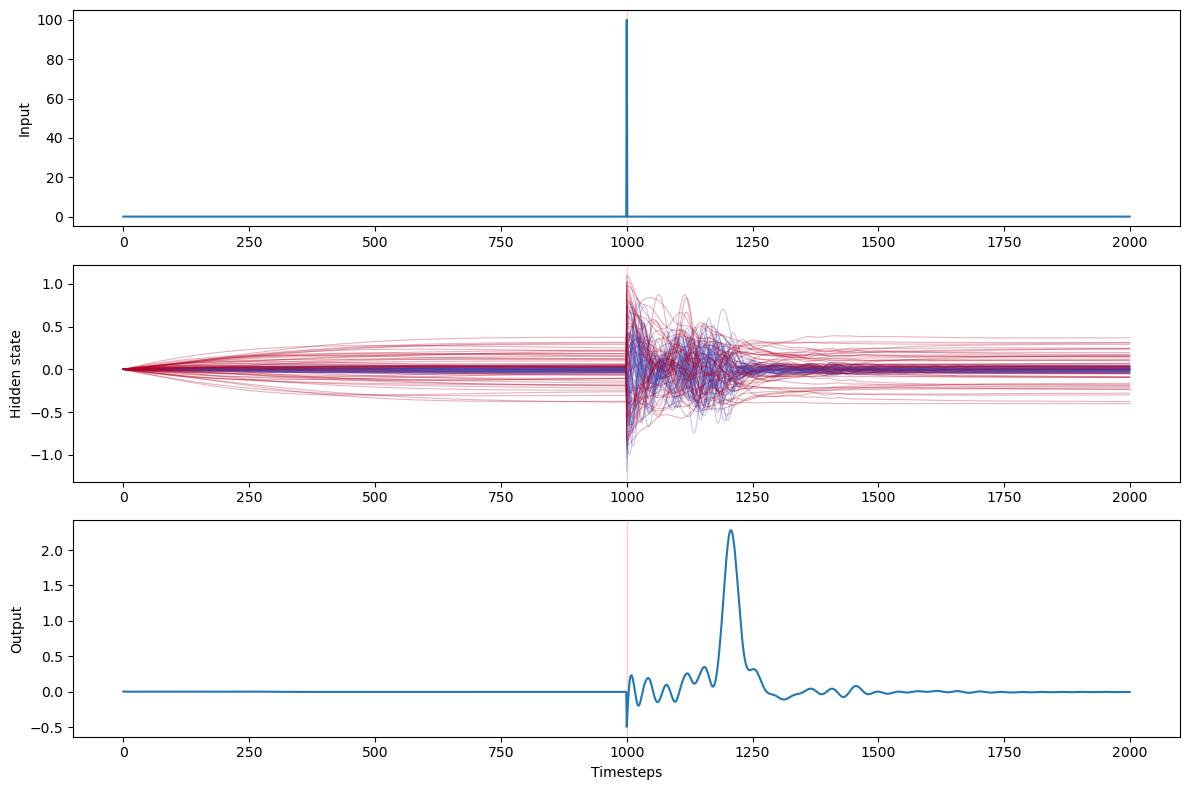

In [49]:
# create pulse input
T = 2000          # timesteps
pulse_start = 1000
pulse_end = 1001

inputs = torch.zeros(1, T, model_cfg['input_size'])
inputs[0, pulse_start:pulse_end, :] = 100   # pulse

# run model
model.eval()
device = next(model.parameters()).device
inputs = inputs.to(device)
hidden = model.init_hidden(1, device=device)

# collect hidden states at each step
hidden_states = []
outputs = []

with torch.no_grad():
    for t in range(T):
        input_t = inputs[:, t:t+1, :]           # (1, 1, input_size)
        hidden, out = model(input_t, hidden, noise=False)
        hidden_states.append(hidden.cpu().numpy())
        outputs.append(out.cpu().numpy())

hidden_states = np.array(hidden_states).squeeze()  # (T, hidden_size)
outputs = np.array(outputs).squeeze()              # (T, output_size)

# get tau for each unit from the saved state dict
taus = best_model['taus'].numpy()  # (hidden_size,)

# color map: map tau value to color
tau_unique = np.unique(taus)
cmap = plt.cm.coolwarm
tau_norm = (taus - taus.min()) / (taus.max() - taus.min())  # normalize to [0,1]
colors = cmap(tau_norm) # blue is fast red is slow

# plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# input pulse
axes[0].plot(inputs.cpu().squeeze())
axes[0].axvspan(pulse_start, pulse_end, alpha=0.2, color='red', label='pulse')
axes[0].set_ylabel('Input')
# axes[0].legend()

# hidden states colored by tau
for i in range(model_cfg['hidden_size']):
    axes[1].plot(hidden_states[:, i], alpha=0.3, linewidth=0.8, color=colors[i])
axes[1].axvspan(pulse_start, pulse_end, alpha=0.2, color='red')
axes[1].set_ylabel('Hidden state')

# # colorbar for tau
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(taus.min(), taus.max()))
# plt.colorbar(sm, ax=axes[1], label='τ', orientation='vertical')

# output
axes[2].plot(outputs)
axes[2].axvspan(pulse_start, pulse_end, alpha=0.2, color='red')
axes[2].set_ylabel('Output')
axes[2].set_xlabel('Timesteps')

plt.tight_layout()
plt.show()

Variance explained: [0.3196218  0.46832126 0.5592256 ]


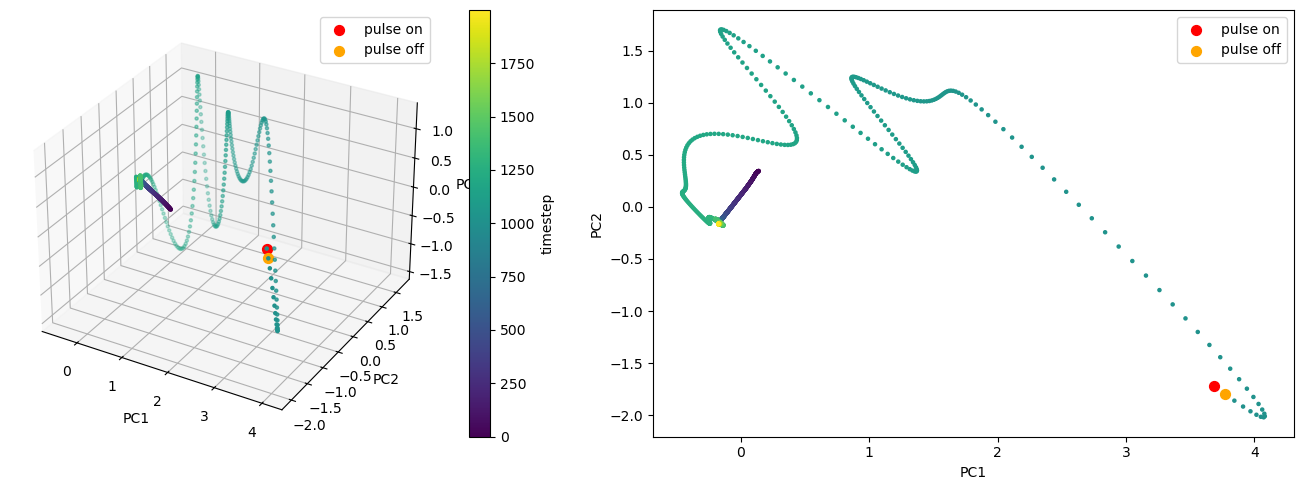

In [50]:
from sklearn.decomposition import PCA

# --- PCA on hidden states ---
pca = PCA(n_components=3)
hidden_pca = pca.fit_transform(hidden_states)  # (T, 3)

print(f"Variance explained: {pca.explained_variance_ratio_.cumsum()}")

# --- plot ---
fig = plt.figure(figsize=(14, 5))

# 3D trajectory
ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(hidden_pca[:, 0], hidden_pca[:, 1], hidden_pca[:, 2],
                      c=np.arange(T), cmap='viridis', s=5)
# mark pulse
ax1.scatter(*hidden_pca[pulse_start], color='red', s=50, label='pulse on', zorder=5)
ax1.scatter(*hidden_pca[pulse_end], color='orange', s=50, label='pulse off', zorder=5)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.set_zlabel('PC3')
ax1.legend()
plt.colorbar(scatter, ax=ax1, label='timestep')

# 2D projections
ax2 = fig.add_subplot(122)
ax2.scatter(hidden_pca[:, 0], hidden_pca[:, 1], c=np.arange(T), cmap='viridis', s=5)
ax2.scatter(*hidden_pca[pulse_start, :2], color='red', s=50, label='pulse on')
ax2.scatter(*hidden_pca[pulse_end, :2], color='orange', s=50, label='pulse off')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend()

plt.tight_layout()
plt.show()

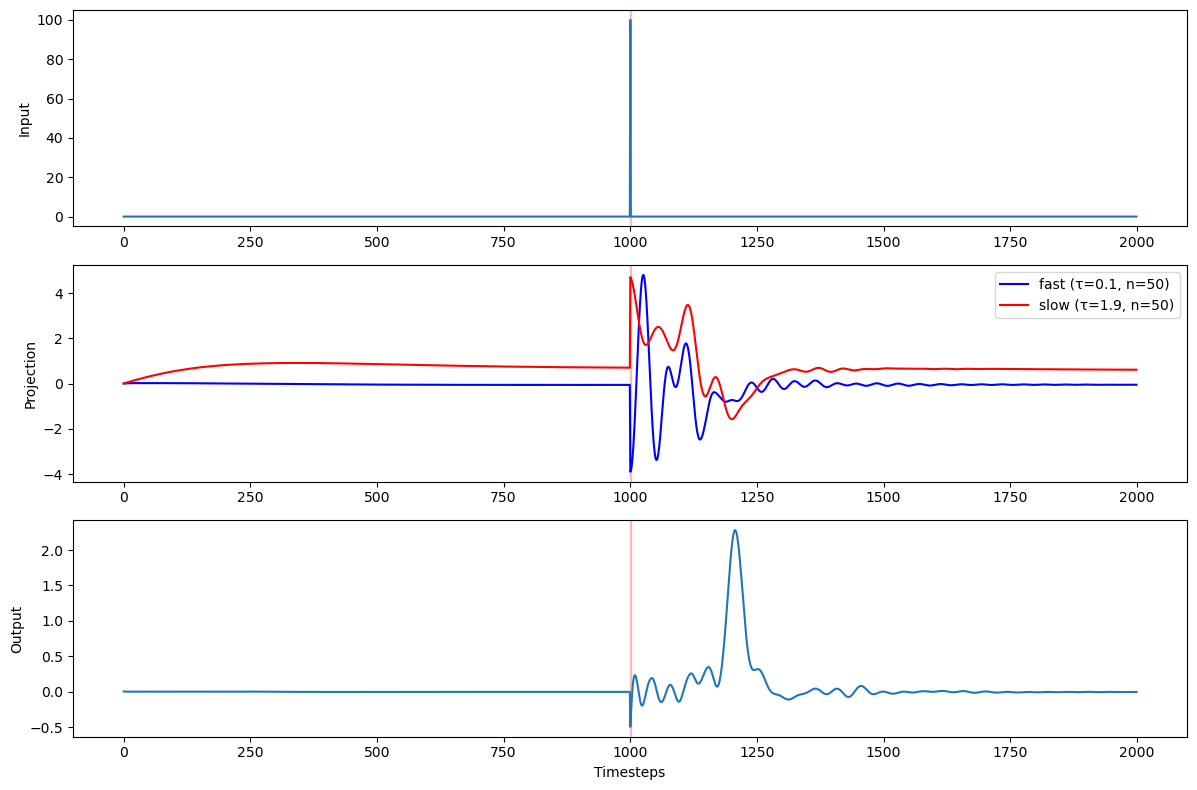

In [61]:
dim1 = (taus < 1).astype(int)
dim2 = (taus > 1).astype(int)

# project: weighted sum of hidden states by each dimension
proj1 = hidden_states @ dim1   # (T,)  fast units
proj2 = hidden_states @ dim2   # (T,)  slow units

# plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(inputs.cpu().squeeze())
axes[0].axvspan(pulse_start, pulse_end, alpha=0.2, color='red')
axes[0].set_ylabel('Input')

axes[1].plot(proj1, color='blue', label=f'fast (τ=0.1, n={dim1.sum()})')
axes[1].plot(proj2, color='red', label=f'slow (τ=1.9, n={dim2.sum()})')
axes[1].axvspan(pulse_start, pulse_end, alpha=0.2, color='red')
axes[1].set_ylabel('Projection')
axes[1].legend()

axes[2].plot(outputs)
axes[2].axvspan(pulse_start, pulse_end, alpha=0.2, color='red')
axes[2].set_ylabel('Output')
axes[2].set_xlabel('Timesteps')

plt.tight_layout()
plt.show()

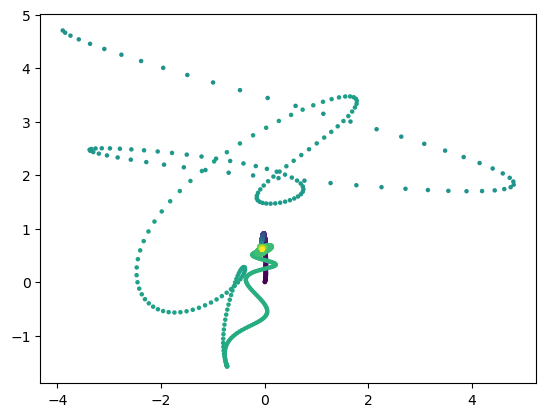

In [63]:
plt.scatter(proj1, proj2, c=np.arange(T), cmap='viridis', s=5)